In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/resnet18-f37072fd-pth/resnet18-f37072fd.pth
/kaggle/input/resnet50/resnet50_weights_tf_dim_ordering_tf_kernels_notop (3).h5
/kaggle/input/mvtec-ad/readme.txt
/kaggle/input/mvtec-ad/license.txt
/kaggle/input/mvtec-ad/wood/readme.txt
/kaggle/input/mvtec-ad/wood/license.txt
/kaggle/input/mvtec-ad/wood/ground_truth/hole/000_mask.png
/kaggle/input/mvtec-ad/wood/ground_truth/hole/003_mask.png
/kaggle/input/mvtec-ad/wood/ground_truth/hole/004_mask.png
/kaggle/input/mvtec-ad/wood/ground_truth/hole/005_mask.png
/kaggle/input/mvtec-ad/wood/ground_truth/hole/001_mask.png
/kaggle/input/mvtec-ad/wood/ground_truth/hole/006_mask.png
/kaggle/input/mvtec-ad/wood/ground_truth/hole/008_mask.png
/kaggle/input/mvtec-ad/wood/ground_truth/hole/007_mask.png
/kaggle/input/mvtec-ad/wood/ground_truth/hole/002_mask.png
/kaggle/input/mvtec-ad/wood/ground_truth/hole/009_mask.png
/kaggle/input/mvtec-ad/wood/ground_truth/liquid/000_mask.png
/kaggle/input/mvtec-ad/wood/ground_truth/liquid/003_mask.png
/k

In [3]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os


In [5]:
import os
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image

class MVTecDataset(Dataset):
    def __init__(self, root_dir, transform=None, mode="train"):
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode  # "train" or "test"
        self.samples = []
        self.classes = []

        # Loop through objects (bottle, cable, etc.)
        for obj in os.listdir(root_dir):
            obj_path = os.path.join(root_dir, obj)
            if not os.path.isdir(obj_path):
                continue

            mode_path = os.path.join(obj_path, mode)
            if not os.path.exists(mode_path):
                continue

            # For train → only good images
            if mode == "train":
                defect_types = ["good"]
            else:  # For test → multiple defects
                defect_types = os.listdir(mode_path)

            for defect in defect_types:
                defect_path = os.path.join(mode_path, defect)
                if not os.path.isdir(defect_path):
                    continue

                class_name = f"{obj}_{defect}"
                if class_name not in self.classes:
                    self.classes.append(class_name)

                class_idx = self.classes.index(class_name)

                for fname in os.listdir(defect_path):
                    fpath = os.path.join(defect_path, fname)
                    self.samples.append((fpath, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)
        return img, label


In [6]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [7]:
root_dir = "/kaggle/input/mvtec-ad"

train_dataset = MVTecDataset(root_dir, transform=transform, mode="train")
test_dataset  = MVTecDataset(root_dir, transform=transform, mode="test")

print("Num train samples:", len(train_dataset))
print("Num test samples:", len(test_dataset))
print("Num classes:", len(train_dataset.classes))
print("Example classes:", train_dataset.classes[:10])


Num train samples: 3629
Num test samples: 1725
Num classes: 15
Example classes: ['wood_good', 'screw_good', 'metal_nut_good', 'capsule_good', 'hazelnut_good', 'carpet_good', 'pill_good', 'grid_good', 'zipper_good', 'transistor_good']


In [8]:
class MVTecDataset(Dataset):
    def __init__(self, root_dir, transform=None, mode="train"):
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode
        self.samples = []
        self.classes = []

        for obj in os.listdir(root_dir):
            obj_path = os.path.join(root_dir, obj)
            if not os.path.isdir(obj_path):
                continue

            mode_path = os.path.join(obj_path, mode)
            if not os.path.exists(mode_path):
                continue

            # include all subfolders (good + defects)
            defect_types = os.listdir(mode_path)

            for defect in defect_types:
                defect_path = os.path.join(mode_path, defect)
                if not os.path.isdir(defect_path):
                    continue

                class_name = f"{obj}_{defect}"
                if class_name not in self.classes:
                    self.classes.append(class_name)

                class_idx = self.classes.index(class_name)

                for fname in os.listdir(defect_path):
                    fpath = os.path.join(defect_path, fname)
                    self.samples.append((fpath, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


In [9]:
root_dir = "/kaggle/input/mvtec-ad"

train_dataset = MVTecDataset(root_dir, transform=transform, mode="train")
test_dataset  = MVTecDataset(root_dir, transform=transform, mode="test")

print("Num train samples:", len(train_dataset))
print("Num test samples:", len(test_dataset))
print("Num classes:", len(test_dataset.classes))
print("Example classes:", test_dataset.classes[:20])


Num train samples: 3629
Num test samples: 1725
Num classes: 88
Example classes: ['wood_good', 'wood_hole', 'wood_liquid', 'wood_scratch', 'wood_color', 'wood_combined', 'screw_good', 'screw_thread_top', 'screw_scratch_neck', 'screw_thread_side', 'screw_scratch_head', 'screw_manipulated_front', 'metal_nut_good', 'metal_nut_bent', 'metal_nut_flip', 'metal_nut_scratch', 'metal_nut_color', 'capsule_good', 'capsule_poke', 'capsule_squeeze']


In [10]:
from torch.utils.data import random_split

# merge train + test samples
all_samples = train_dataset.samples + test_dataset.samples
all_classes = train_dataset.classes  # same as test_dataset.classes

# rebuild dataset with merged samples
class CombinedDataset(Dataset):
    def __init__(self, samples, classes, transform=None):
        self.samples = samples
        self.classes = classes
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

combined_dataset = CombinedDataset(all_samples, all_classes, transform=transform)

# split into train/val
train_size = int(0.8 * len(combined_dataset))
val_size = len(combined_dataset) - train_size
train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size])


In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)


In [12]:
import torch

# Device configuration (GPU if available, else CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import torch.nn as nn
from torchvision import models

# Example: num_classes = 88 (from your dataset)
num_classes = 88

# Load pretrained ResNet50
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s] 


In [13]:
import torch.optim as optim

# Hyperparameters
learning_rate = 1e-4
batch_size = 32
num_epochs = 20

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


In [14]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [15]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for batch_idx, (imgs, labels) in enumerate(train_loader, 1):
        imgs, labels = imgs.to(device), labels.to(device)

        # Forward pass
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Track stats
        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

        # Print batch progress
        if batch_idx % 10 == 0 or batch_idx == len(train_loader):  
            batch_acc = 100. * correct / total
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Batch [{batch_idx}/{len(train_loader)}] "
                  f"Loss: {running_loss/batch_idx:.4f} "
                  f"Acc: {batch_acc:.2f}%")

    # Epoch summary
    epoch_acc = 100. * correct / total
    print(f"==> Epoch [{epoch+1}/{num_epochs}] Finished | "
          f"Loss: {running_loss/len(train_loader):.4f} | "
          f"Train Acc: {epoch_acc:.2f}%\n")


Epoch [1/20] Batch [10/134] Loss: 3.1045 Acc: 54.38%
Epoch [1/20] Batch [20/134] Loss: 2.5822 Acc: 60.47%
Epoch [1/20] Batch [30/134] Loss: 2.3146 Acc: 63.96%
Epoch [1/20] Batch [40/134] Loss: 2.1877 Acc: 65.00%
Epoch [1/20] Batch [50/134] Loss: 2.0479 Acc: 65.94%
Epoch [1/20] Batch [60/134] Loss: 1.9678 Acc: 66.20%
Epoch [1/20] Batch [70/134] Loss: 1.8736 Acc: 66.96%
Epoch [1/20] Batch [80/134] Loss: 1.8232 Acc: 66.88%
Epoch [1/20] Batch [90/134] Loss: 1.7836 Acc: 66.49%
Epoch [1/20] Batch [100/134] Loss: 1.7403 Acc: 66.50%
Epoch [1/20] Batch [110/134] Loss: 1.6755 Acc: 67.19%
Epoch [1/20] Batch [120/134] Loss: 1.6409 Acc: 67.19%
Epoch [1/20] Batch [130/134] Loss: 1.6082 Acc: 67.09%
Epoch [1/20] Batch [134/134] Loss: 1.5908 Acc: 67.17%
==> Epoch [1/20] Finished | Loss: 1.5908 | Train Acc: 67.17%

Epoch [2/20] Batch [10/134] Loss: 1.0088 Acc: 70.00%
Epoch [2/20] Batch [20/134] Loss: 1.0668 Acc: 68.75%
Epoch [2/20] Batch [30/134] Loss: 1.0774 Acc: 68.12%
Epoch [2/20] Batch [40/134] Loss

In [16]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

test_acc = 100. * correct / total
print(f"Test Accuracy: {test_acc:.2f}%")


Test Accuracy: 92.29%


In [17]:
torch.save(model.state_dict(), "resnet50_mvtec_20epochs.pth")


In [33]:
import torch
import torch.nn as nn
from torchvision import models

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the model architecture
num_classes = 88  # your dataset classes
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Load trained weights
model.load_state_dict(torch.load("resnet50_mvtec_30epochs.pth", map_location=device))
model = model.to(device)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

                            precision    recall  f1-score   support

                 wood_good       0.86      1.00      0.93        19
                 wood_hole       0.47      0.90      0.62        10
               wood_liquid       0.56      1.00      0.71        10
              wood_scratch       0.83      0.90      0.86        21
                wood_color       0.89      1.00      0.94         8
             wood_combined       1.00      1.00      1.00        11
                screw_good       0.66      0.90      0.76        41
          screw_thread_top       0.55      0.78      0.64        23
        screw_scratch_neck       0.73      0.88      0.80        25
         screw_thread_side       0.66      0.83      0.73        23
        screw_scratch_head       0.79      0.92      0.85        24
   screw_manipulated_front       1.00      0.96      0.98        24
            metal_nut_good       0.89      0.77      0.83        22
            metal_nut_bent       0.72      0.92

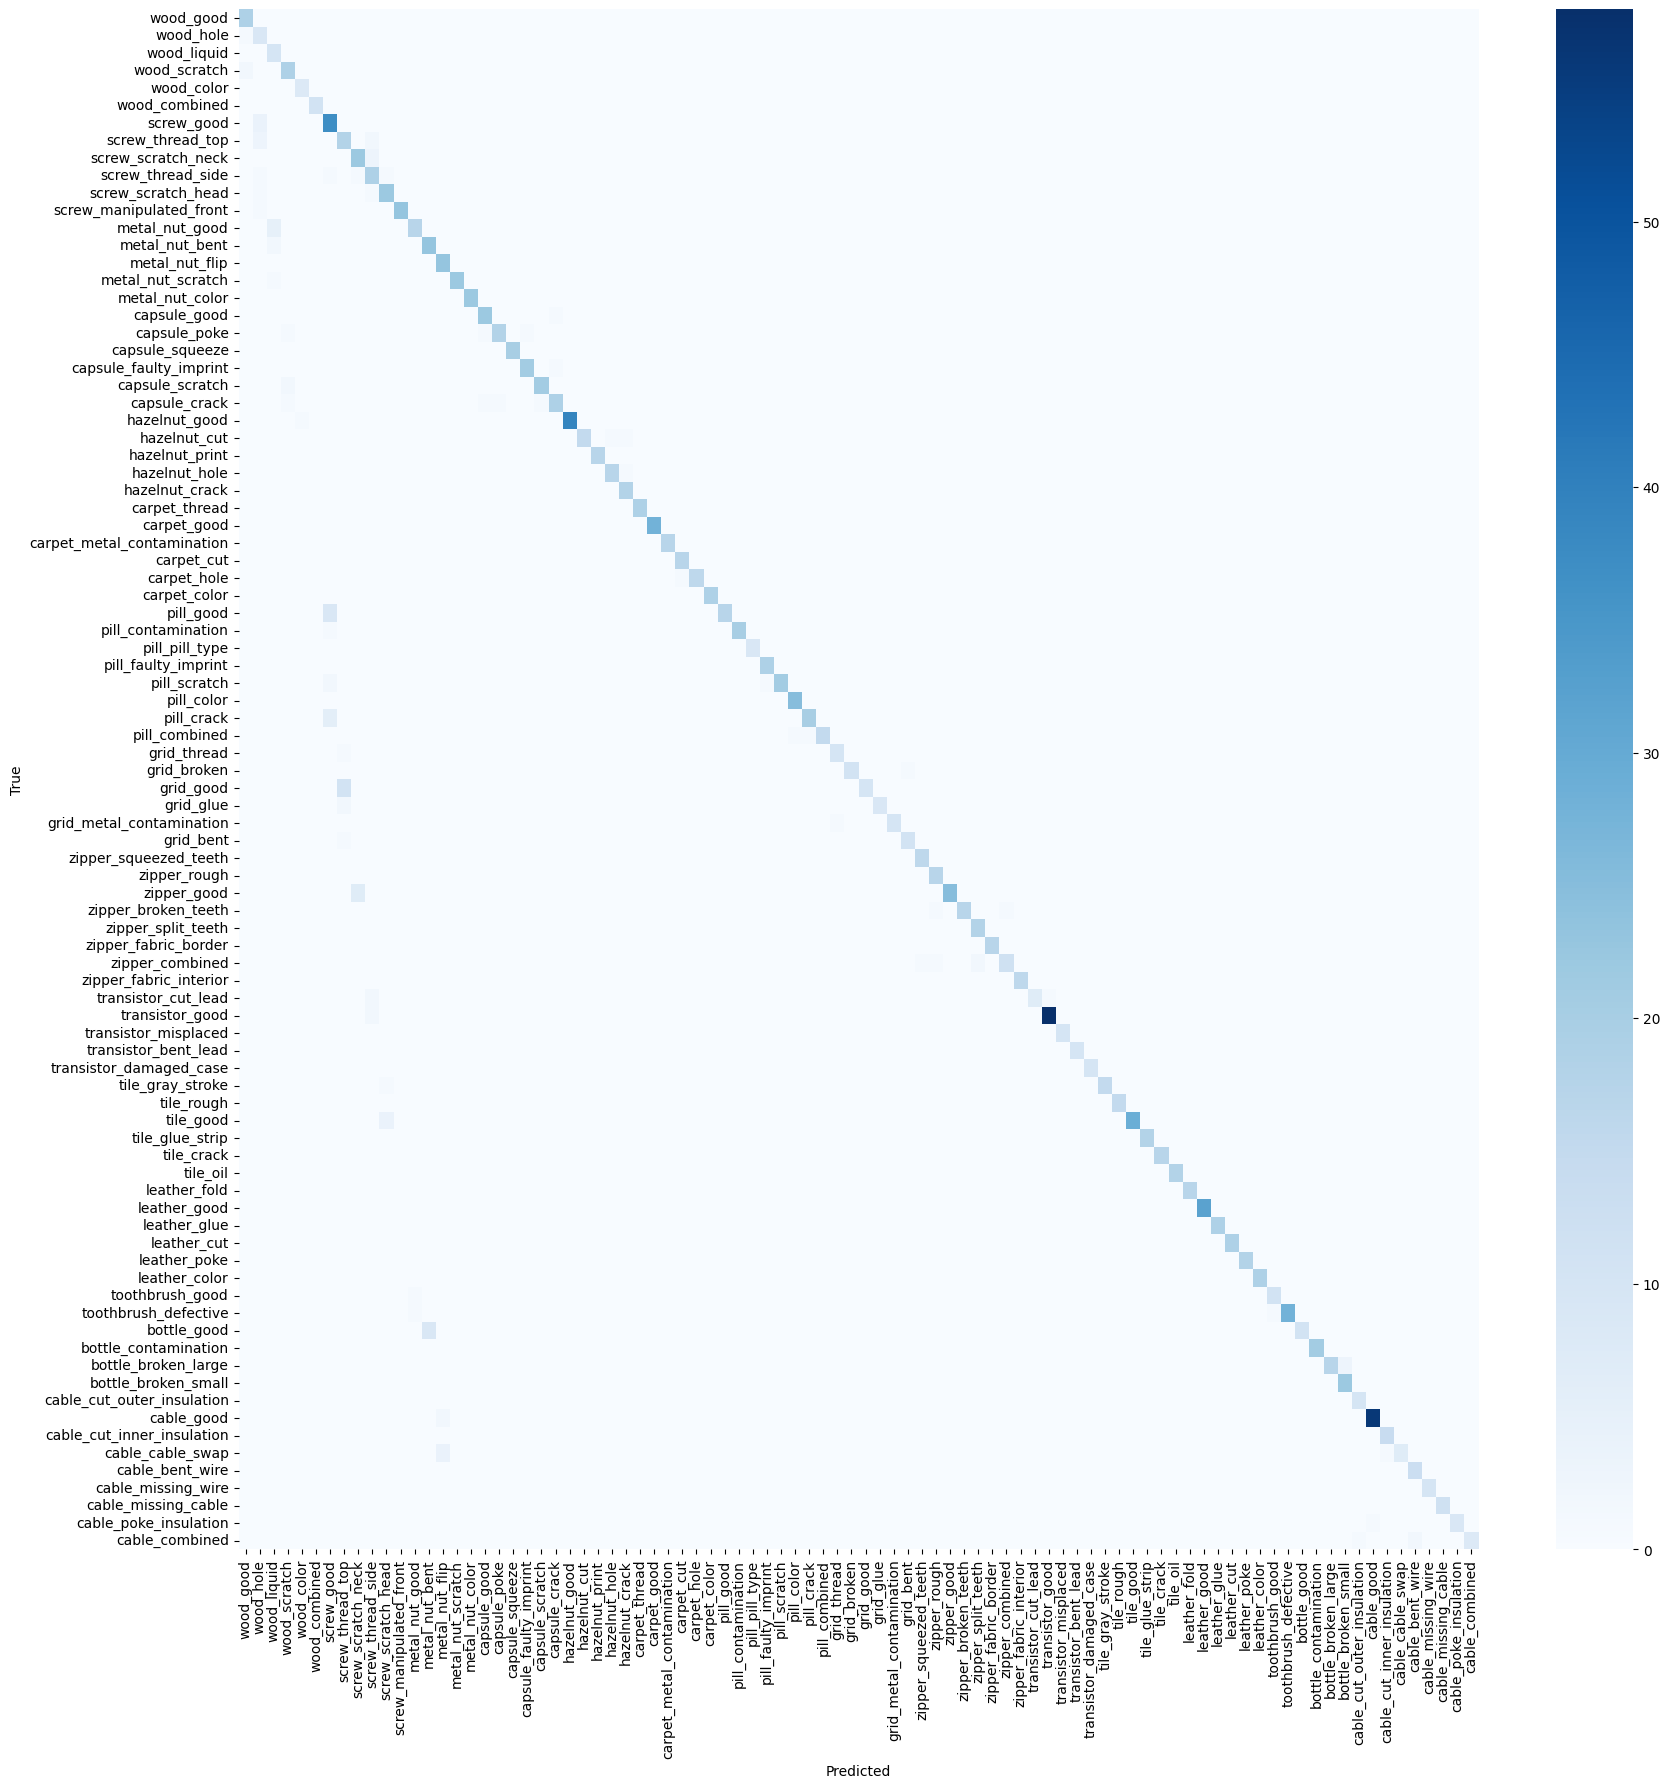

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Classification report
print(classification_report(y_true, y_pred, target_names=test_dataset.classes))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=test_dataset.classes,
            yticklabels=test_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [19]:
from PIL import Image
import torch
from torchvision import transforms

# Define same transform as used during test
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

def predict_single_image(model, image_path, classes, device):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)  # Add batch dim

    with torch.no_grad():
        outputs = model(img_tensor)
        _, pred = outputs.max(1)
        predicted_class = classes[pred.item()]
    
    return predicted_class

# Example usage:
image_path = "/kaggle/input/mvtec-ad/tile/test/crack/007.png"  # change this path
pred_class = predict_single_image(model, image_path, test_dataset.classes, device)
print(f"Predicted: {pred_class}")


Predicted: wood_hole


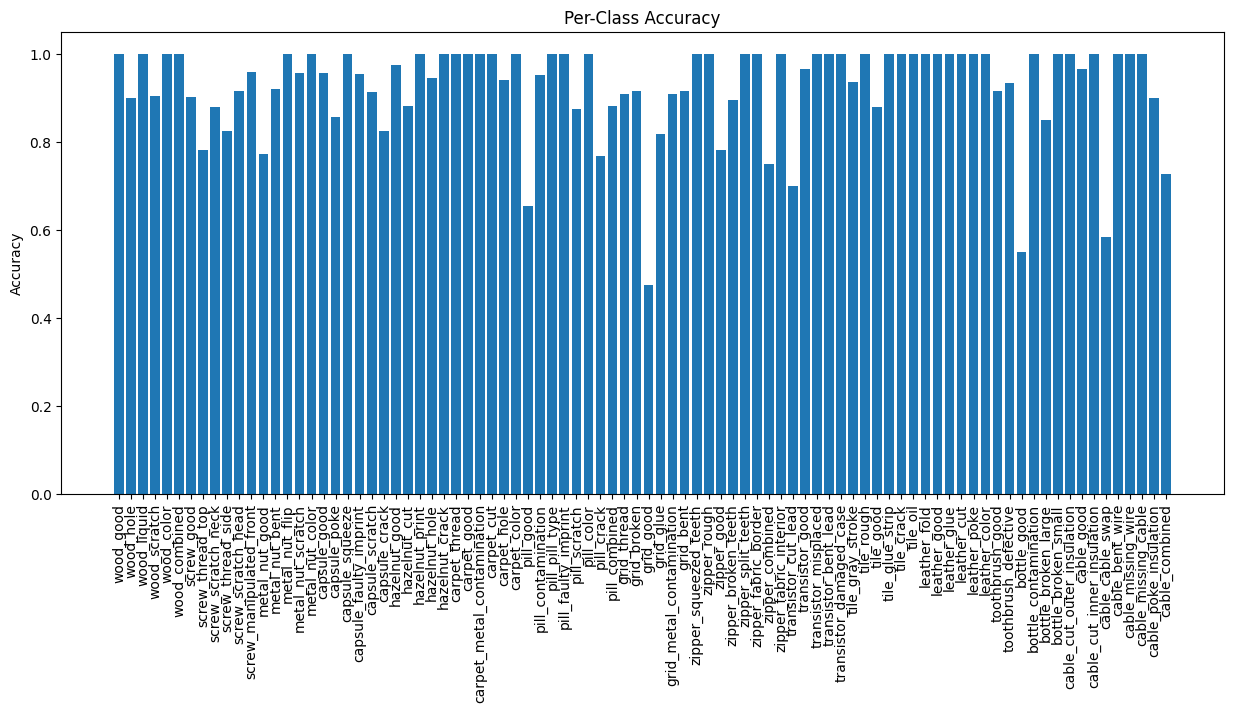

In [20]:
import numpy as np

class_correct = np.zeros(len(test_dataset.classes))
class_total = np.zeros(len(test_dataset.classes))

for i in range(len(y_true)):
    label = y_true[i]
    pred = y_pred[i]
    if label == pred:
        class_correct[label] += 1
    class_total[label] += 1

class_acc = class_correct / class_total

plt.figure(figsize=(15, 6))
plt.bar(range(len(test_dataset.classes)), class_acc)
plt.xticks(range(len(test_dataset.classes)), test_dataset.classes, rotation=90)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.show()


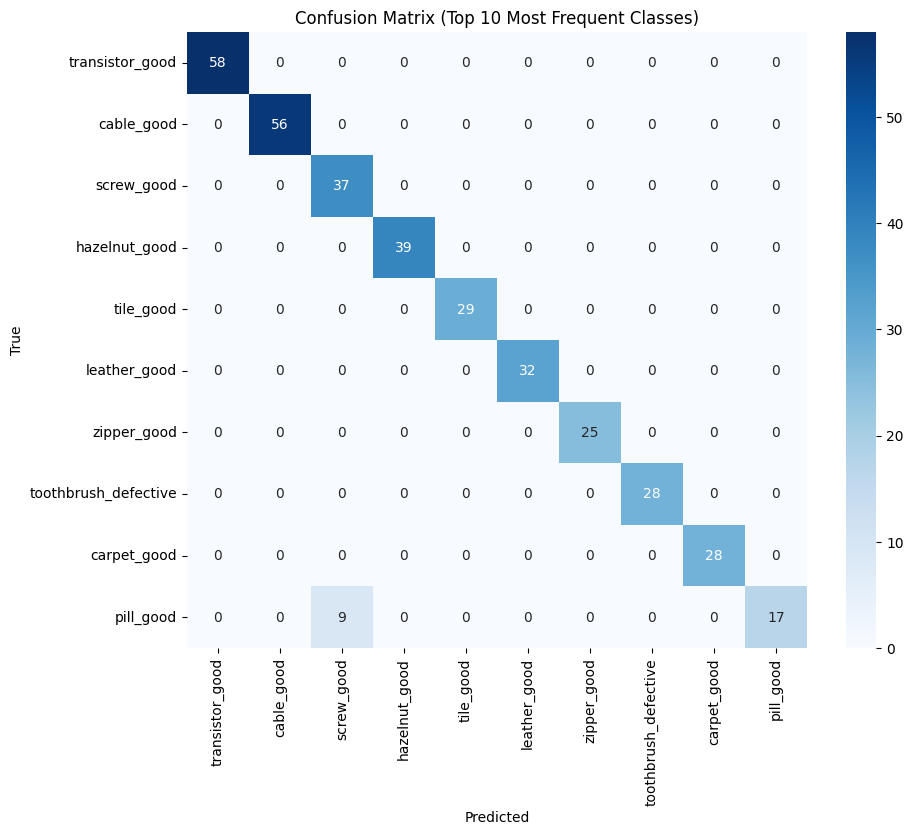

In [22]:
import seaborn as sns

# Find top 10 most frequent classes
class_counts = np.bincount(all_labels)
top_classes = np.argsort(class_counts)[::-1][:10]

cm_top = cm[np.ix_(top_classes, top_classes)]

plt.figure(figsize=(10,8))
sns.heatmap(cm_top, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.array(test_dataset.classes)[top_classes],
            yticklabels=np.array(test_dataset.classes)[top_classes])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Top 10 Most Frequent Classes)")
plt.show()


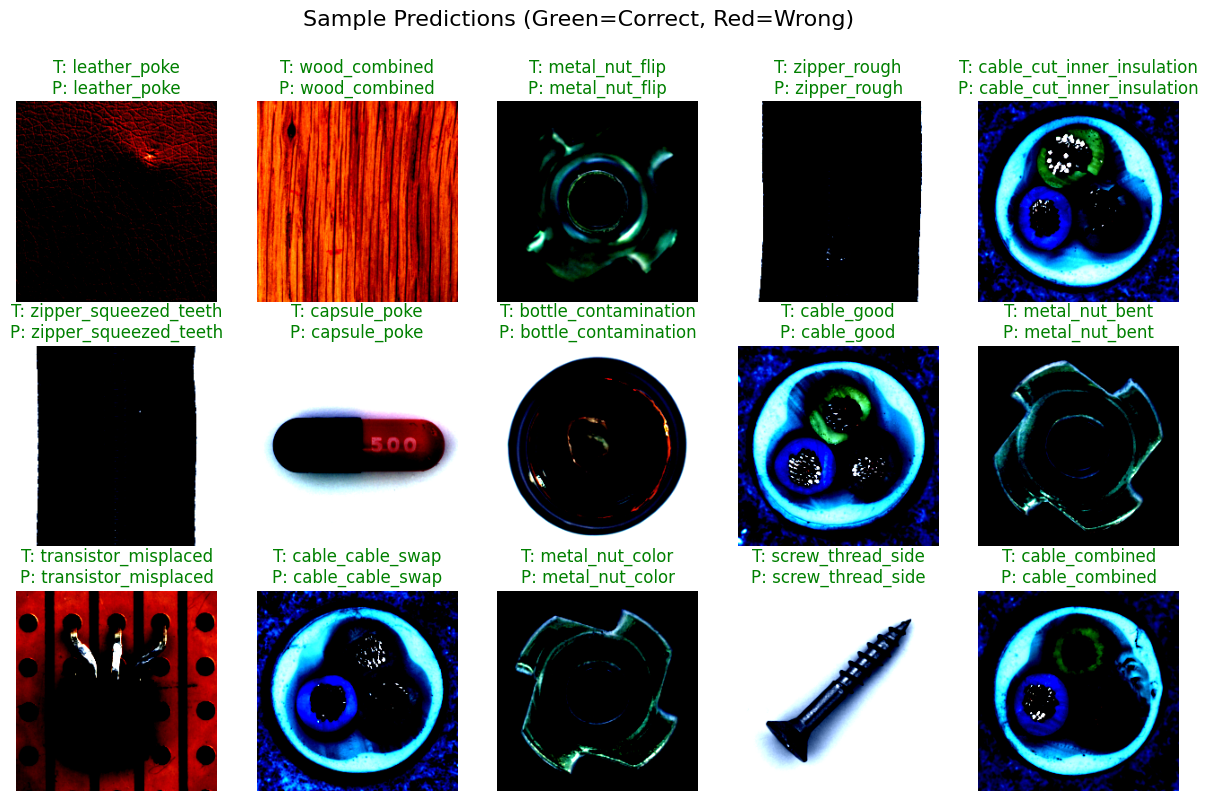

In [23]:
import random
from torchvision.utils import make_grid

# Pick random samples
model.eval()
fig, axs = plt.subplots(3, 5, figsize=(15, 9))

for ax in axs.flat:
    idx = random.randint(0, len(test_dataset)-1)
    img, label = test_dataset[idx]
    img_tensor = img.unsqueeze(0).to(device)
    output = model(img_tensor)
    _, pred = output.max(1)
    
    img_np = img.permute(1,2,0).numpy()  # to HWC
    true_label = test_dataset.classes[label]
    pred_label = test_dataset.classes[pred.item()]
    
    ax.imshow(img_np)
    ax.set_title(f"T: {true_label}\nP: {pred_label}",
                 color="green" if label == pred.item() else "red")
    ax.axis("off")

plt.suptitle("Sample Predictions (Green=Correct, Red=Wrong)", fontsize=16)
plt.show()


In [ ]:
assert os.path.exists('C:\Users\Baji\Downloadsresnet50_mvtec_20epochs.pth'), "Model file not found!"


In [4]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 88
model = models.resnet50(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Load weights
model.load_state_dict(torch.load("resnet50_mvtec_20epochs.pth", map_location=device))
model = model.to(device)
model.eval()  # set to evaluation mode


FileNotFoundError: [Errno 2] No such file or directory: 'resnet50_mvtec_20epochs.pth'

In [1]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Overall Accuracy:", accuracy_score(y_true, y_pred))
print("Macro Precision:", precision_score(y_true, y_pred, average="macro"))
print("Macro Recall:", recall_score(y_true, y_pred, average="macro"))
print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_true, y_pred, average="weighted"))


NameError: name 'y_true' is not defined

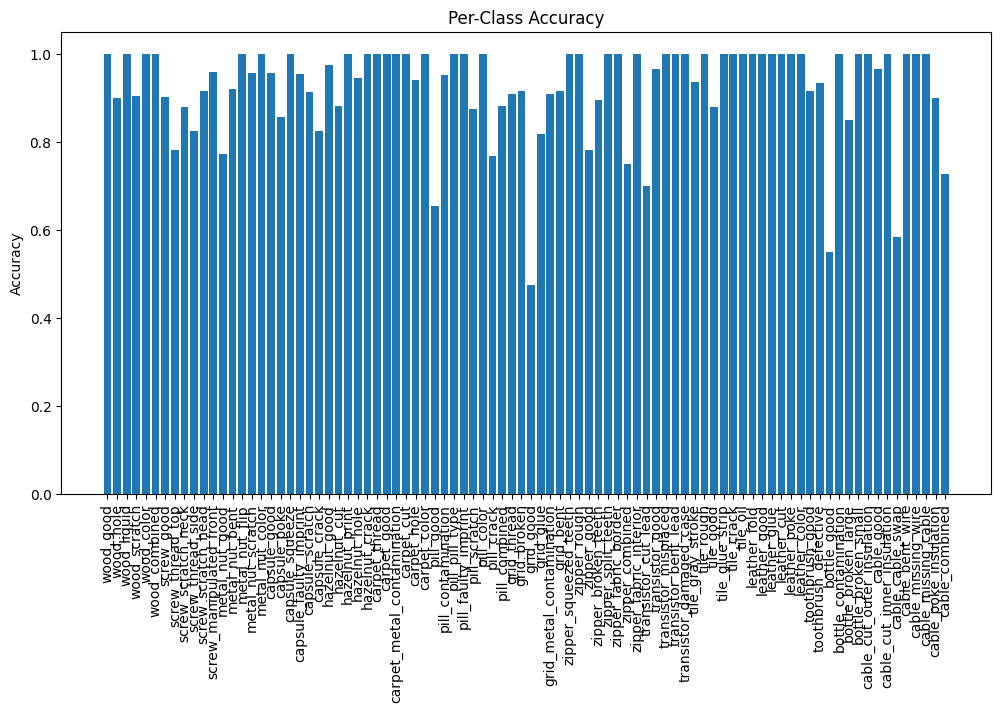

In [25]:
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
class_acc = cm.diagonal() / cm.sum(axis=1)

plt.figure(figsize=(12,6))
plt.bar(range(len(class_acc)), class_acc)
plt.xticks(range(len(class_acc)), test_dataset.classes, rotation=90)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.show()


In [34]:
import os
print(os.getcwd())        # current working directory
print(os.listdir())       # list all files there


/kaggle/working
['resnet50_mvtec_20epochs.pth', '.virtual_documents']


In [38]:
from IPython.display import FileLink
FileLink(r'resnet50_mvtec_20epochs.pth')


/kaggle/working/resnet50_mvtec_20epochs.pth